### Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scirpy as ir
import scanpy as sc

C:\Users\wwspa\miniconda3\envs\tcr_scripts\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import glob
import os
from pathlib import Path

sample_directory = './Parse_sequencing/'

Data loading works but little overlap between WT and TCR data, WT and TCR filtering is done by trailmaker but not explained
- current workaround: Load all AIRR TSV files seperately from each donor, annotate samples and convert to scirpy for downstream processing, this does not include a cell QC per se (since no WT data) but only the trailmaker TCR QC when loading TCR_filtered data (also possible to load TCR_unfiltered data)

Loading GEX and TCR this way seems to work, next combine GEX AND TCR, also use unfiltered TCR and DGE later for processing

Barely any overlap between WT and TCR

Load  TCR files seperately from each donor

GP33 TCR unfiltered

Loading function

In [3]:
import pandas as pd
from pathlib import Path
from typing import Literal, Optional
import scirpy as ir

tcr_gene_columns = ['IR_VJ_1_c_call',
 'IR_VJ_2_c_call',
 'IR_VDJ_1_c_call',
 'IR_VDJ_2_c_call',
 'IR_VJ_1_d_call',
 'IR_VJ_2_d_call',
 'IR_VDJ_1_d_call',
 'IR_VDJ_2_d_call',
 'IR_VJ_1_j_call',
 'IR_VJ_2_j_call',
 'IR_VDJ_1_j_call',
 'IR_VDJ_2_j_call',
 'IR_VJ_1_v_call',
 'IR_VJ_2_v_call',
 'IR_VDJ_1_v_call',
 'IR_VDJ_2_v_call']

def load_parse_tcr(
    path_str: str,
    tcr_filter: Literal["filtered", "unfiltered"],
    filename: str,
    n_files: int,
    experiment_name: str,
    specificity: str,
    additional_path_str: Optional[str] = None,
):
    """
    Load and integrate TCR AIRR data from one or two Parse Biosciences sequencing runs.

    Parameters
    ----------
    path_str : str
        Path to the first TCR data directory (required).
    tcr_filter : Literal["filtered", "unfiltered"]
        Whether to use filtered or unfiltered TCRs.
    filename : str
        Common prefix for donor subfolder names, e.g., 'm38_pa_m'.
    n_files : int
        Number of donors to load (e.g., 37 for m1..m37).
    experiment_name : str
        Annotation for experiment metadata.
    specificity : str
        Antigen or specificity label.
    additional_path_str : str, optional
        Optional second path to integrate data from (e.g., another sequencing run).
    """

    def _load_one_path(base_path: Path):
        dfs = []
        for i in range(1, n_files + 1):
            subfolder = base_path / f"{filename}{i}" / f"TCR_{tcr_filter}"
            if not subfolder.exists():
                print(f"Warning: {subfolder} does not exist, skipping.")
                continue

            tsv_files = list(subfolder.glob("tcr_annotation_airr.tsv"))
            if not tsv_files:
                print(f"No TSV found in {subfolder}, skipping.")
                continue

            df = pd.read_csv(tsv_files[0], sep="\t")
            df["mouse"] = f"{filename}{i}"
            dfs.append(df)
        return dfs

    # Load from main path
    dfs = _load_one_path(Path(path_str))

    # Load from optional second path
    if additional_path_str is not None:
        print(f"\nIntegrating additional TCR data from: {additional_path_str}")
        dfs += _load_one_path(Path(additional_path_str))

    # Combine all donor files
    if not dfs:
        raise ValueError("No TCR data could be loaded from the provided paths.")
    tcr_df = pd.concat(dfs, ignore_index=True)
    tcr_df.rename(columns={"cell_barcode": "cell_id"}, inplace=True)

    # Convert to AnnData
    adata_tcr = ir.io.read_airr(tcr_df)

    # Clean NaNs in obs
    for col in adata_tcr.obs.columns:
        adata_tcr.obs[col] = adata_tcr.obs[col].astype(str)
        adata_tcr.obs[col] = adata_tcr.obs[col].replace("nan", "None").fillna("None").astype("category")

    # Annotate metadata
    adata_tcr.obs["cell_id"] = adata_tcr.obs.index.astype("category")
    mapping = tcr_df.drop_duplicates(subset="cell_id").set_index("cell_id")["mouse"]
    adata_tcr.obs["mouse"] = adata_tcr.obs["cell_id"].map(mapping)
    adata_tcr.obs["experiment"] = experiment_name
    adata_tcr.obs["isolated_specificity"] = specificity

    # Chain QC and filtering
    ir.tl.chain_qc(adata_tcr)
    print(f"Before filtering: {adata_tcr.n_obs}")
    ax = ir.pl.group_abundance(adata_tcr, groupby="chain_pairing", target_col="mouse", legend=False)
    ax.legend_.remove()

    adata_tcr = adata_tcr[adata_tcr.obs["has_ir"] != "None", :].copy()
    adata_tcr = adata_tcr[~adata_tcr.obs["chain_pairing"].isin(["orphan VDJ", "orphan VJ"]), :].copy()
    print(f"After filtering: {adata_tcr.n_obs}")

    ax = ir.pl.group_abundance(adata_tcr, groupby="chain_pairing", target_col="mouse")
    ax.legend_.remove()

    #process gene annotations
    for col in tcr_gene_columns:
        if col in adata_tcr.obs.columns:
            adata_tcr.obs[col] = adata_tcr.obs[col].astype(str).str.replace(r"(_[12])$", "", regex=True) #removes the "_1" or "_2" nomenclature of parse TCR genes to match with previous data
        
    return adata_tcr

def reactivity_threshold(df, exp=int, anot_epitope=str):
    tcr_list = df.TCR[df.TCR_expansion>=exp].unique().tolist()
    df.loc[:, 'sequencing_specificity'] = 'below_threshold'
    mask = df['TCR'].isin(tcr_list)
    df.loc[mask, 'sequencing_specificity'] = anot_epitope
    #df = df[df.annot_react_thresh == anot_epitope].copy()
    print('reactive TCRs: ' + str(df.TCR[df.sequencing_specificity == anot_epitope].nunique()))
    return df
    

GP33

No expression information available. Cannot rank chains by expression. 


Before filtering: 255027
After filtering: 66022


C:\Users\wwspa\AppData\Local\Temp\ipykernel_20948\2415811149.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tcr_df = pd.concat(dfs, ignore_index=True)
No expression information available. Cannot rank chains by expression. 


Before filtering: 51889
After filtering: 28476


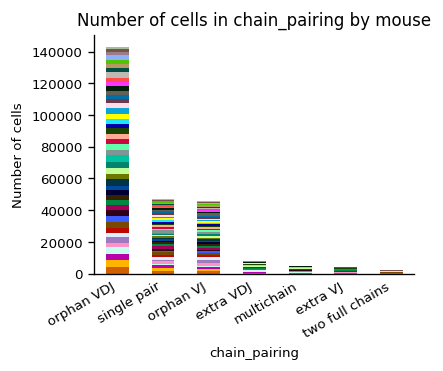

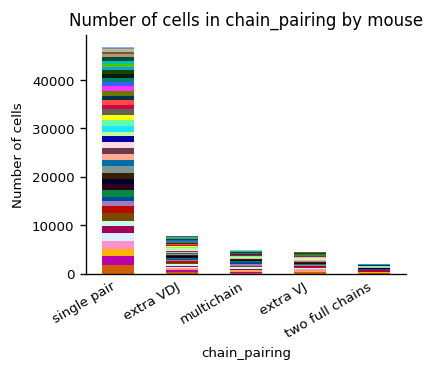

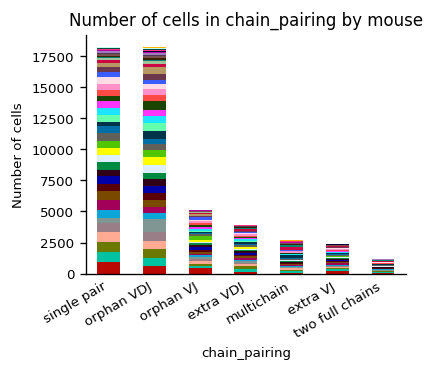

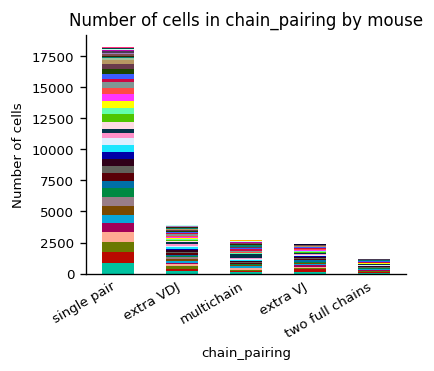

In [4]:
gp33_unfiltered = load_parse_tcr(path_str = "./Parse_sequencing/gp33 tcr files/immune_output_combined",
                           tcr_filter = 'unfiltered',
                           filename="gp33_m", 
                           n_files=48,
                           experiment_name = "2_pa_gp33",
                           specificity = 'GP33',
                           additional_path_str = None)

gp33_filtered = load_parse_tcr(path_str = "./Parse_sequencing/gp33 tcr files/immune_output_combined",
                           tcr_filter = 'filtered',
                           filename="gp33_m", 
                           n_files=48,
                           experiment_name = "2_pa_gp33",
                           specificity = 'GP33',
                           additional_path_str = None)

# flag Traimaker single cell filter in unfiltered data
filtered_ids = gp33_filtered.obs.cell_id.tolist()
#unfiltered_ids = gp33_unfiltered.obs.cell_id.tolist()
#overlap = [cellid for cellid in filtered_ids if cellid in unfiltered_ids]

gp33_unfiltered.obs["trailmaker_QC"] = 'no_pass'
filtered_mask = gp33_unfiltered.obs.cell_id.isin(filtered_ids)
gp33_unfiltered.obs.loc[filtered_mask, "trailmaker_QC"] = 'pass'
gp33_unfiltered.obs["trailmaker_QC"] = gp33_unfiltered.obs["trailmaker_QC"].astype('category')



In [5]:
df_obs = pd.DataFrame(gp33_unfiltered.obs)

for col in df_obs.columns:
    if isinstance(df_obs[col].dtype, pd.CategoricalDtype):
        categories = df_obs[col].cat.categories
        
        if all(isinstance(x, str) for x in categories):
            df_obs[col] = df_obs[col].astype("string")

In [6]:
from preprocess_tcr_2 import preprocess_tcr_vj_vdj

df = preprocess_tcr_vj_vdj(df_obs)
df2 = reactivity_threshold(df, exp=3,anot_epitope = 'GP33')
df2 = df2[~df2.TCR.str.contains('None')].reset_index(drop=True).copy()

reactive TCRs: 4243


In [7]:
df2['isolated_specificity'] = 'GP33'
df2['mouse'] = df2['mouse'].astype('string') + '_' + df2['isolated_specificity']
df2['NAME'] = df2['cell_id'].copy()
df2['donor_id'] = df2['mouse']
df2['biosample_id'] = df2['experiment']
df2['species'] = 'NCBITaxon_10090'
df2['species__strain'] = 'C57BL/6'
df2['species__ontology_label'] = 'Mus musculus'
df2['disease'] = 'MONDO_0005828'
df2['disease__strain'] = 'lymphocytic_choriomeningitis_virus_armstrong'
df2['disease__ontology_label'] = 'lymphocytic choriomeningitis'
df2['disease__epitope'] = 'KAVYNFATC'
df2['disease__antigen'] = 'GP33'
df2['disease__timepoint'] = 'd8'
df2['organ'] = 'UBERON_0002106'
df2['organ__ontology_label'] = 'spleen'
df2['library_preparation_protocol'] = 'EFO_0009919'
df2['library_preparation_protocol__ontology_label'] = "SPLiT-seq"
df2['cell_type'] = "CL_0000625"
df2['cell_type__ontology_label'] = "CD8-positive, alpha-beta T cell"
df2['sex'] = 'female'

In [8]:
tcr_file_cols =  ['multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call',
       'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_d_call',
       'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call',
       'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call',
       'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction',
       'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa',
       'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa',
       'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus',
       'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive',
       'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call',
       'IR_VDJ_1_v_call', 'IR_VDJ_2_v_call', 'has_ir', 'cell_id', 'mouse',
       'experiment', 'isolated_specificity', 'receptor_type',
       'receptor_subtype', 'chain_pairing', 'assigned_TRA',
       'assigned_TRB', 'TRB', 'TRA', 'TCR', 'TCR_expansion',
       'TCR_expansion_full_data', 'TRA2', 'TRB2', 'dual_tcr', 'n_cells_mouse',
       'sequencing_specificity', 'NAME', 'donor_id', 'biosample_id', 'species',
       'species__strain', 'species__ontology_label', 'disease',
       'disease__strain', 'disease__ontology_label', 'disease__epitope',
       'disease__antigen', 'disease__timepoint', 'organ',
       'organ__ontology_label', 'library_preparation_protocol',
       'library_preparation_protocol__ontology_label', 'cell_type',
       'cell_type__ontology_label', 'sex']

meta_data_cols = ['NAME', 'donor_id', 'biosample_id', 'species',
       'species__strain', 'species__ontology_label', 'disease',
       'disease__strain', 'disease__ontology_label', 'disease__epitope',
       'disease__antigen', 'disease__timepoint', 'organ',
       'organ__ontology_label', 'library_preparation_protocol',
       'library_preparation_protocol__ontology_label', 'cell_type',
       'cell_type__ontology_label', 'sex']

In [9]:
obs_filename = 'parse_gp33_obs_df'
tcr_filename = 'parse_gp33_tcr_data'
meta_filename = 'parse_gp33_metadata'

tcr_data = df2[tcr_file_cols]
tcr_data.to_csv("./Parse_sequencing/" + obs_filename + ".csv", index=False)
tcr_data.to_csv(
    "./Parse_sequencing/" + tcr_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)
metadata = df2[meta_data_cols]
metadata.to_csv(
    "./Parse_sequencing/" + meta_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)

M38


Integrating additional TCR data from: ./Parse_sequencing/M38_TCR_only_files/immune_output_combined


No expression information available. Cannot rank chains by expression. 


Before filtering: 18321
After filtering: 4129

Integrating additional TCR data from: ./Parse_sequencing/M38_TCR_only_files/immune_output_combined


No expression information available. Cannot rank chains by expression. 


Before filtering: 9481
After filtering: 3662


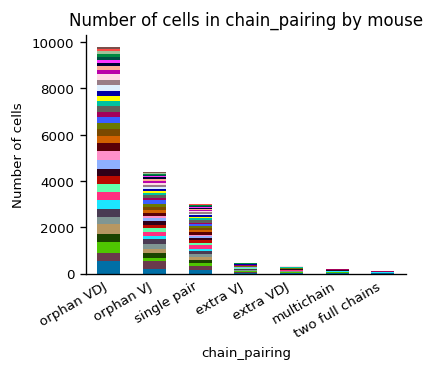

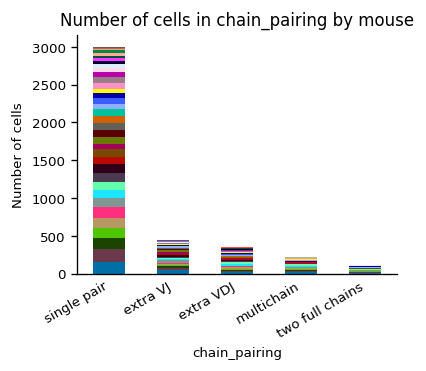

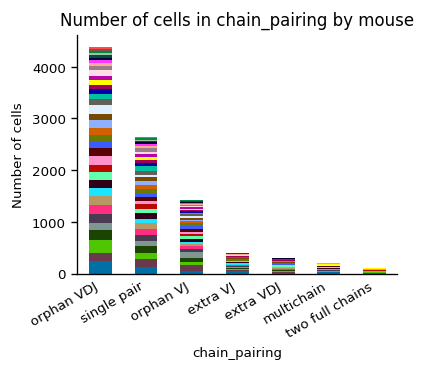

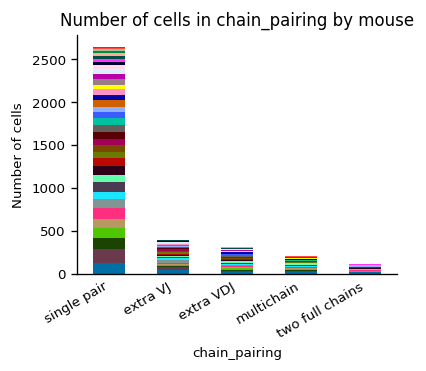

In [10]:
m38_unfiltered = load_parse_tcr(path_str = "./Parse_sequencing/m38 n4 naive TCR files/immune_output_combined",
                           tcr_filter = 'unfiltered',
                           filename="m38_pa_m", 
                           n_files=36,
                           experiment_name = "1_pa_m38",
                           specificity = 'M38',
                           additional_path_str = "./Parse_sequencing/M38_TCR_only_files/immune_output_combined")

m38_filtered = load_parse_tcr(path_str = "./Parse_sequencing/m38 n4 naive TCR files/immune_output_combined",
                           tcr_filter = 'filtered',
                           filename="m38_pa_m", 
                           n_files=36,
                           experiment_name = "1_pa_m38",
                           specificity = 'M38',
                           additional_path_str = "./Parse_sequencing/M38_TCR_only_files/immune_output_combined")

# flag Traimaker single cell filter in unfiltered data
filtered_ids = m38_filtered.obs.cell_id.tolist()
#unfiltered_ids = gp33_unfiltered.obs.cell_id.tolist()
#overlap = [cellid for cellid in filtered_ids if cellid in unfiltered_ids]

m38_unfiltered.obs["trailmaker_QC"] = 'no_pass'
filtered_mask = m38_unfiltered.obs.cell_id.isin(filtered_ids)
m38_unfiltered.obs.loc[filtered_mask, "trailmaker_QC"] = 'pass'
m38_unfiltered.obs["trailmaker_QC"] = m38_unfiltered.obs["trailmaker_QC"].astype('category')

In [11]:
df_obs = pd.DataFrame(m38_unfiltered.obs)

for col in df_obs.columns:
    if isinstance(df_obs[col].dtype, pd.CategoricalDtype):
        categories = df_obs[col].cat.categories
        
        if all(isinstance(x, str) for x in categories):
            df_obs[col] = df_obs[col].astype("string")
			
from preprocess_tcr_2 import preprocess_tcr_vj_vdj

df = preprocess_tcr_vj_vdj(df_obs)
df2 = reactivity_threshold(df, exp=3,anot_epitope = 'M38')
df2 = df2[~df2.TCR.str.contains('None')].reset_index(drop=True).copy()

df2['isolated_specificity'] = 'M38'
df2['mouse'] = df2['mouse'].astype('string') + '_' + df2['isolated_specificity']
df2['NAME'] = df2['cell_id'].copy()
df2['donor_id'] = df2['mouse']
df2['biosample_id'] = df2['experiment']
df2['species'] = 'NCBITaxon_10090'
df2['species__strain'] = 'C57BL/6'
df2['species__ontology_label'] = 'Mus musculus'
df2['disease'] = 'MONDO_0005132'
df2['disease__strain'] = 'murine_cytomegalovirus_wildtype'
df2['disease__ontology_label'] = 'cytomegalovirus infection'
df2['disease__epitope'] = 'SSPPMFRV'
df2['disease__antigen'] = 'M38'
df2['disease__timepoint'] = 'd8'
df2['organ'] = 'UBERON_0002106'
df2['organ__ontology_label'] = 'spleen'
df2['library_preparation_protocol'] = 'EFO_0009919'
df2['library_preparation_protocol__ontology_label'] = "SPLiT-seq"
df2['cell_type'] = "CL_0000625"
df2['cell_type__ontology_label'] = "CD8-positive, alpha-beta T cell"
df2['sex'] = 'female'


reactive TCRs: 272


In [12]:
obs_filename = 'parse_m38_obs_df'
tcr_filename = 'parse_m38_tcr_data'
meta_filename = 'parse_m38_metadata'

tcr_data = df2[tcr_file_cols]
tcr_data.to_csv("./Parse_sequencing/" + obs_filename + ".csv", index=False)
tcr_data.to_csv(
    "./Parse_sequencing/" + tcr_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)
metadata = df2[meta_data_cols]
metadata.to_csv(
    "./Parse_sequencing/" + meta_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)

N4


Integrating additional TCR data from: ./Parse_sequencing/M38_TCR_only_files/immune_output_combined


No expression information available. Cannot rank chains by expression. 


Before filtering: 15334
After filtering: 4365

Integrating additional TCR data from: ./Parse_sequencing/M38_TCR_only_files/immune_output_combined


No expression information available. Cannot rank chains by expression. 


Before filtering: 7582
After filtering: 3725


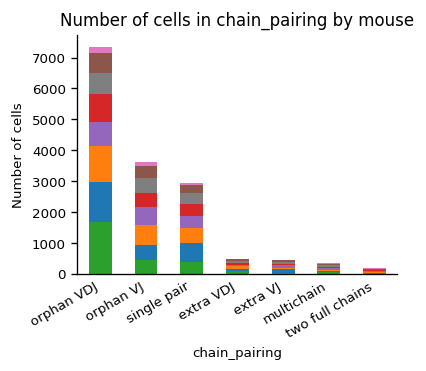

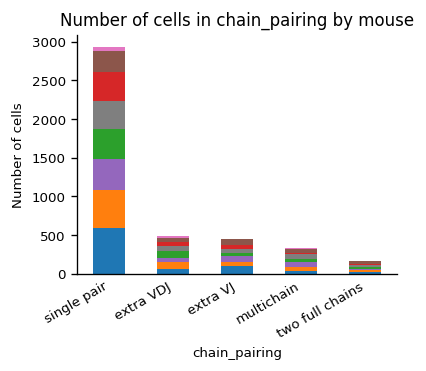

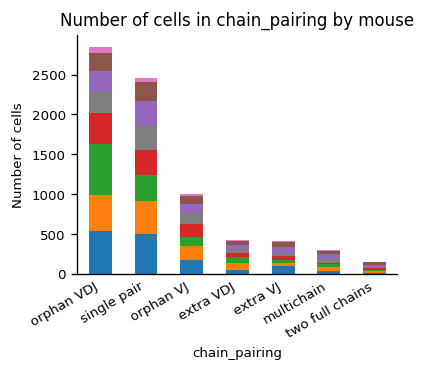

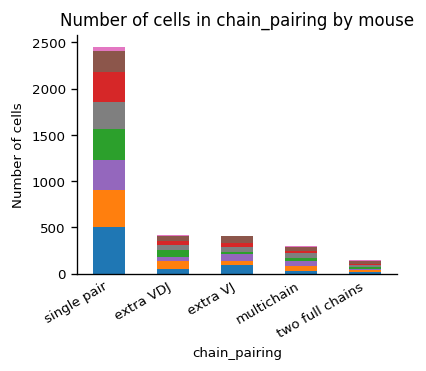

In [13]:
n4_unfiltered = load_parse_tcr(path_str = "./Parse_sequencing/m38 n4 naive TCR files/immune_output_combined",
                           tcr_filter = 'unfiltered',
                           filename="n4_pa_m", 
                           n_files=8,
                           experiment_name = "1_pa_n4",
                           specificity = 'OVA',
                           additional_path_str = "./Parse_sequencing/M38_TCR_only_files/immune_output_combined")

n4_filtered = load_parse_tcr(path_str = "./Parse_sequencing/m38 n4 naive TCR files/immune_output_combined",
                           tcr_filter = 'filtered',
                           filename="n4_pa_m", 
                           n_files=8,
                           experiment_name = "1_pa_n4",
                           specificity = 'OVA',
                           additional_path_str = "./Parse_sequencing/M38_TCR_only_files/immune_output_combined")

# flag Traimaker single cell filter in unfiltered data
filtered_ids = n4_filtered.obs.cell_id.tolist()
#unfiltered_ids = gp33_unfiltered.obs.cell_id.tolist()
#overlap = [cellid for cellid in filtered_ids if cellid in unfiltered_ids]

n4_unfiltered.obs["trailmaker_QC"] = 'no_pass'
filtered_mask = n4_unfiltered.obs.cell_id.isin(filtered_ids)
n4_unfiltered.obs.loc[filtered_mask, "trailmaker_QC"] = 'pass'
n4_unfiltered.obs["trailmaker_QC"] = n4_unfiltered.obs["trailmaker_QC"].astype('category')



In [14]:
df_obs = pd.DataFrame(n4_unfiltered.obs)

for col in df_obs.columns:
    if isinstance(df_obs[col].dtype, pd.CategoricalDtype):
        categories = df_obs[col].cat.categories
        
        if all(isinstance(x, str) for x in categories):
            df_obs[col] = df_obs[col].astype("string")
			
from preprocess_tcr_2 import preprocess_tcr_vj_vdj

df = preprocess_tcr_vj_vdj(df_obs)
df2 = reactivity_threshold(df, exp=3,anot_epitope = 'OVA')
df2 = df2[~df2.TCR.str.contains('None')].reset_index(drop=True).copy()

df2['isolated_specificity'] = 'OVA'
df2['mouse'] = df2['mouse'].astype('string') + '_' + df2['isolated_specificity']
df2['NAME'] = df2['cell_id'].copy()
df2['donor_id'] = df2['mouse']
df2['biosample_id'] = df2['experiment']
df2['species'] = 'NCBITaxon_10090'
df2['species__strain'] = 'C57BL/6'
df2['species__ontology_label'] = 'Mus musculus'
df2['disease'] = 'MONDO_0005828'
df2['disease__strain'] = 'Listeria_monocytogenes_OVA'
df2['disease__ontology_label'] = 'listeriosis'
df2['disease__epitope'] = 'SIINFEKL'
df2['disease__antigen'] = 'OVA'
df2['disease__timepoint'] = 'd8'
df2['organ'] = 'UBERON_0002106'
df2['organ__ontology_label'] = 'spleen'
df2['library_preparation_protocol'] = 'EFO_0009919'
df2['library_preparation_protocol__ontology_label'] = "SPLiT-seq"
df2['cell_type'] = "CL_0000625"
df2['cell_type__ontology_label'] = "CD8-positive, alpha-beta T cell"
df2['sex'] = 'female'


reactive TCRs: 205


In [15]:
obs_filename = 'parse_ova_obs_df'
tcr_filename = 'parse_ova_tcr_data'
meta_filename = 'parse_ova_metadata'

tcr_data = df2[tcr_file_cols]
tcr_data.to_csv("./Parse_sequencing/" + obs_filename + ".csv", index=False)
tcr_data.to_csv(
    "./Parse_sequencing/" + tcr_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)
metadata = df2[meta_data_cols]
metadata.to_csv(
    "./Parse_sequencing/" + meta_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)

Naive

In [16]:
tcr_file_cols =  ['multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call',
       'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_d_call',
       'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call',
       'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call',
       'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction',
       'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa',
       'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa',
       'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus',
       'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive',
       'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call',
       'IR_VDJ_1_v_call', 'IR_VDJ_2_v_call', 'has_ir', 'cell_id', 'mouse',
       'experiment', 'isolated_specificity', 'receptor_type',
       'receptor_subtype', 'chain_pairing', 'assigned_TRA',
       'assigned_TRB', 'TRB', 'TRA', 'TCR', 'TCR_expansion',
       'TCR_expansion_full_data', 'TRA2', 'TRB2', 'dual_tcr', 'n_cells_mouse',
       'sequencing_specificity', 'NAME', 'donor_id', 'biosample_id', 'species',
       'species__strain', 'species__ontology_label', 'disease',
       'disease__strain', 'disease__ontology_label', 'disease__epitope',
       'disease__antigen', 'organ',
       'organ__ontology_label', 'library_preparation_protocol',
       'library_preparation_protocol__ontology_label', 'cell_type',
       'cell_type__ontology_label', 'sex']

meta_data_cols = ['NAME', 'donor_id', 'biosample_id', 'species',
       'species__strain', 'species__ontology_label', 'disease',
       'disease__strain', 'disease__ontology_label', 'disease__epitope',
       'disease__antigen', 'organ',
       'organ__ontology_label', 'library_preparation_protocol',
       'library_preparation_protocol__ontology_label', 'cell_type',
       'cell_type__ontology_label', 'sex']


Integrating additional TCR data from: ./Parse_sequencing/M38_TCR_only_files/immune_output_combined


No expression information available. Cannot rank chains by expression. 


Before filtering: 4695
After filtering: 1203

Integrating additional TCR data from: ./Parse_sequencing/M38_TCR_only_files/immune_output_combined


No expression information available. Cannot rank chains by expression. 


Before filtering: 2462
After filtering: 1059


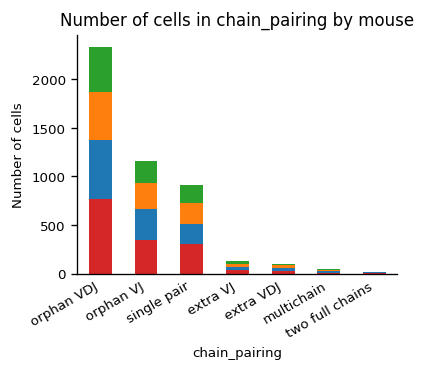

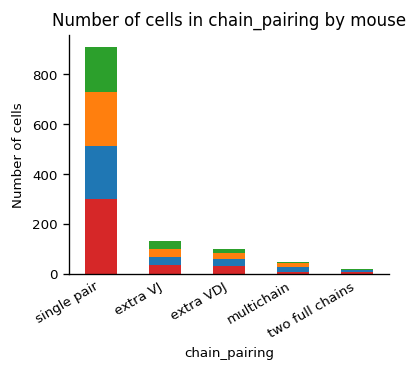

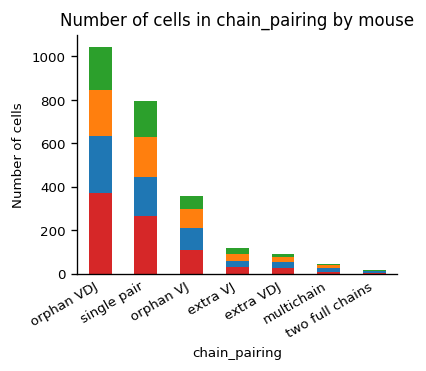

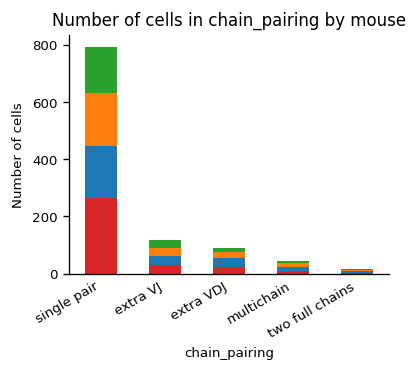

In [17]:
naive_unfiltered = load_parse_tcr(path_str = "./Parse_sequencing/m38 n4 naive TCR files/immune_output_combined",
                           tcr_filter = 'unfiltered',
                           filename="naive_pa_m", 
                           n_files=4,
                           experiment_name = "1_pa_naive",
                           specificity = 'not_identified',
                           additional_path_str = "./Parse_sequencing/M38_TCR_only_files/immune_output_combined")

naive_filtered = load_parse_tcr(path_str = "./Parse_sequencing/m38 n4 naive TCR files/immune_output_combined",
                           tcr_filter = 'filtered',
                           filename="naive_pa_m", 
                           n_files=4,
                           experiment_name = "1_pa_naive",
                           specificity = 'not_identified',
                           additional_path_str = "./Parse_sequencing/M38_TCR_only_files/immune_output_combined")

# flag Traimaker single cell filter in unfiltered data
filtered_ids = naive_filtered.obs.cell_id.tolist()
#unfiltered_ids = gp33_unfiltered.obs.cell_id.tolist()
#overlap = [cellid for cellid in filtered_ids if cellid in unfiltered_ids]

naive_unfiltered.obs["trailmaker_QC"] = 'no_pass'
filtered_mask = naive_unfiltered.obs.cell_id.isin(filtered_ids)
naive_unfiltered.obs.loc[filtered_mask, "trailmaker_QC"] = 'pass'
naive_unfiltered.obs["trailmaker_QC"] = naive_unfiltered.obs["trailmaker_QC"].astype('category')
naive_unfiltered.obs["mouse"] = naive_unfiltered.obs["mouse"].str.replace("naive_pa_","", regex=False)

In [18]:
df_obs = pd.DataFrame(naive_unfiltered.obs)

for col in df_obs.columns:
    if isinstance(df_obs[col].dtype, pd.CategoricalDtype):
        categories = df_obs[col].cat.categories
        
        if all(isinstance(x, str) for x in categories):
            df_obs[col] = df_obs[col].astype("string")
			
from preprocess_tcr_2 import preprocess_tcr_vj_vdj

df = preprocess_tcr_vj_vdj(df_obs)
df = df[~df.TCR.str.contains('None')].reset_index(drop=True).copy()

df2['isolated_specificity'] = 'naive'
df['NAME'] = df['cell_id'].copy()
df['donor_id'] = df['mouse']
df['biosample_id'] = df['experiment']
df['species'] = 'NCBITaxon_10090'
df['species__strain'] = 'C57BL/6'
df['species__ontology_label'] = 'Mus musculus'
df['disease'] = 'PATO_0000461'
df['disease__strain'] = 'uninfected'
df['disease__ontology_label'] = 'normal'
df['disease__epitope'] = 'none'
df['disease__antigen'] = 'none'
df['organ'] = 'UBERON_0002106'
df['organ__ontology_label'] = 'spleen'
df['library_preparation_protocol'] = 'EFO_0009919'
df['library_preparation_protocol__ontology_label'] = "SPLiT-seq"
df['cell_type'] = "CL_0000625"
df['cell_type__ontology_label'] = "CD8-positive, alpha-beta T cell"
df['sex'] = 'female'
df['sequencing_specificity'] = 'naive'

In [19]:
obs_filename = 'parse_naive_obs_df'
tcr_filename = 'parse_naive_tcr_data'
meta_filename = 'parse_naive_metadata'

tcr_data = df[tcr_file_cols]
tcr_data.to_csv("./Parse_sequencing/" + obs_filename + ".csv", index=False)
tcr_data.to_csv(
    "./Parse_sequencing/" + tcr_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)
metadata = df[meta_data_cols]
metadata.to_csv(
    "./Parse_sequencing/" + meta_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)